# Image Detection mit einem vortrainierten Netzwerk

## Imports

In [5]:
import torch
from torchvision import models
from torchvision import transforms
from PIL import Image


## Torch Models

In [6]:
dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

In [7]:
alexnet = models.AlexNet()

In [8]:
resnet = models.resnet101(pretrained=True)

In [9]:
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Normalisierung des Bildes

In [10]:
preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )])

## Laden eines Bildes

In [11]:
img = Image.open("tennisball.jpg")

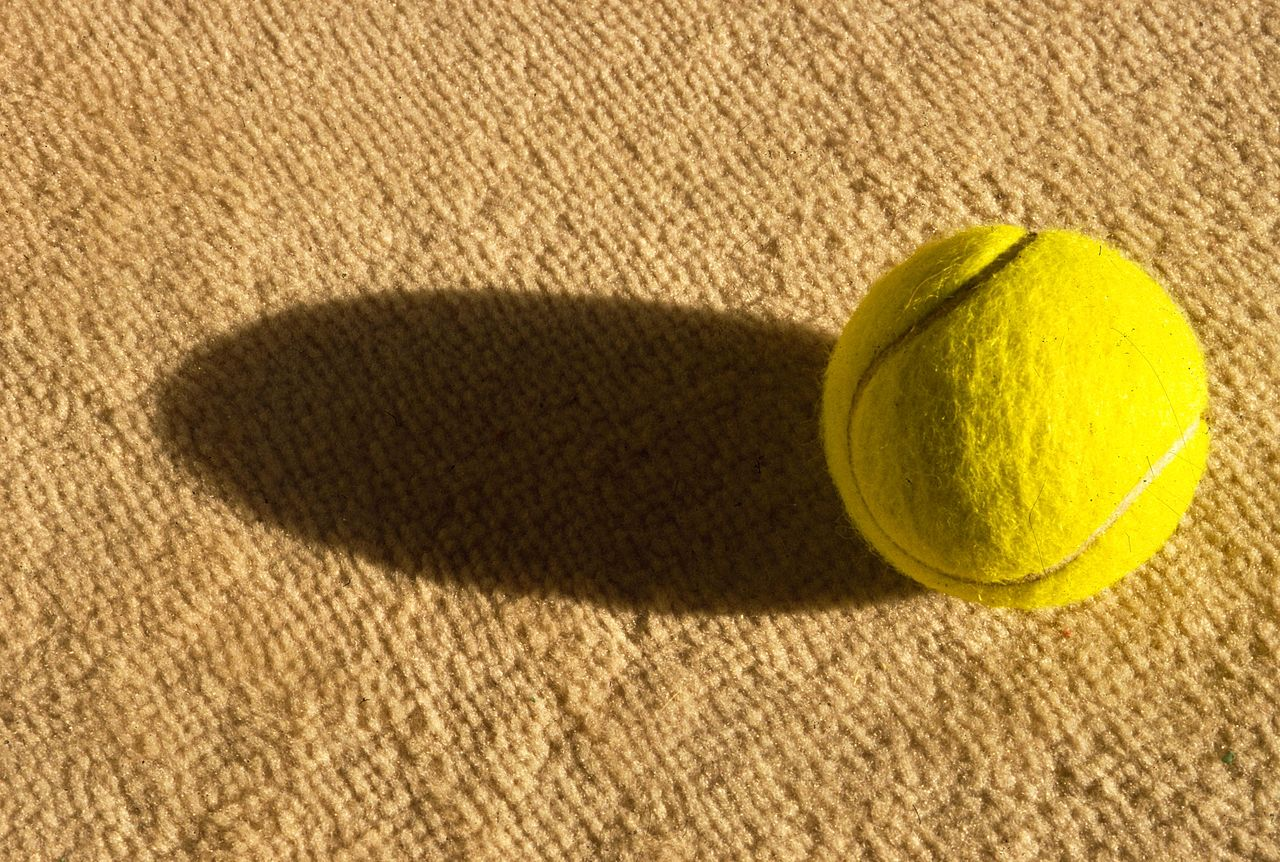

In [12]:
img

In [13]:
img_t = preprocess(img)

## Image Detection

In [14]:
batch_t = torch.unsqueeze(img_t, 0)

In [15]:
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
out = resnet(batch_t)
out

tensor([[-2.3926e+00, -2.4464e+00, -1.3203e+00, -2.4572e+00, -6.9587e-01,
         -8.4034e-01, -9.8278e-01, -6.9916e-01, -1.8380e+00, -1.5925e+00,
         -3.5780e+00,  1.3404e+00, -4.5468e+00, -3.3189e+00, -2.1832e+00,
         -2.2371e+00, -2.0277e+00, -3.1269e+00, -1.6487e+00, -2.6739e+00,
         -2.4389e+00, -5.2947e+00, -5.3856e+00, -4.0014e+00, -3.0831e+00,
          4.7598e-01, -1.5790e+00,  8.6849e-02, -3.2184e-01, -2.3685e+00,
          1.5607e+00,  3.0095e+00,  4.1987e-01, -1.8949e+00,  1.0583e+00,
         -2.1472e+00, -8.6304e-01, -4.7406e-01, -1.3262e+00, -4.0522e-01,
          1.3454e+00, -1.8481e+00, -8.7360e-01, -2.9054e+00, -9.0089e-02,
         -2.7825e-02,  2.3214e+00,  1.9555e+00, -4.6466e-01, -3.1863e+00,
         -1.5434e+00, -1.6306e+00, -1.5672e-01, -2.2225e+00, -1.9111e+00,
          3.2329e+00, -4.9306e-01, -8.2004e-01, -2.6253e+00,  5.6856e-01,
          1.0222e+00, -5.7822e-01, -1.1310e+00, -2.2397e+00,  3.6844e+00,
         -5.8866e-01,  1.1532e+00, -6.

In [17]:
with open('imagenet_classes.txt') as f:
    labels = [line.strip() for line in f.readlines()]

In [18]:
_, index = torch.max(out, 1)

In [19]:
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
labels[index[0]], percentage[index[0]].item()

('tennis ball', 99.81838989257812)

In [20]:
_, indices = torch.sort(out, descending=True)
[(labels[idx], percentage[idx].item()) for idx in indices[0][:5]]

[('tennis ball', 99.81838989257812),
 ('wool, woolen, woollen', 0.06449884176254272),
 ('racket, racquet', 0.04349273070693016),
 ('lemon', 0.015968237072229385),
 ('mitten', 0.006799138616770506)]